In [1]:
!pip install datasets
!pip install evaluate
!pip install fsspec==2023.9.2


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 173.4/173.4 kB 12.9 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cuda-cupti-cu12 12.5.82 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-nvrtc-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64", but you have


⚙️ **Requerimientos importantes sobre el ejercicio**

- El notebook debe ejecutarse **de principio a fin sin intervención manual**.
- Si utilizas librerías que no están incluidas por defecto en Google Colab, **asegúrate de instalarlas dentro del notebook** (por ejemplo: `!pip install ...`).

- Algunas celdas incluyen identificadores especiales que indican ciertas normas que **debes** respetar:
 - `#NO-MODIFY: DATA LOAD`  
    🔒 **No modifiques** el contenido de esta celda.

  - `#NO-MODIFY: VARIABLE NAME`  
    ✏️ Puedes modificar o añadir información **dentro de la celda**, pero **sin cambiar el nombre de la variable asignada**. No incluyas más variables de las existentes en la celda.

  - `#MODIFY: ADD INFO TO SOLVE FUNCTION`  
    🔧 Puedes modificar el **interior de la función** para resolver la tarea, pero **no cambies su nombre, la cabecera ni el `return`**.



## Imports

In [2]:
import numpy as np
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [13]:
# Add your imports here
import collections
from wordcloud import WordCloud
from nltk.corpus import stopwords

import matplotlib.pyplot as plt
import seaborn as sns


!pip install -U transformers

# 🔍 Ejercicio1: Detección de profesiones en tweets

## Enunciado

En este ejercicio vamos a trabajar con un conjunto de datos procedente de medios sociales online.

Utilizaremos un subconjunto de los datos de la tarea 1 del shared task [**ProfNER**](https://temu.bsc.es/smm4h-spanish), centrada en la detección de menciones a profesiones en tweets publicados durante la pandemia del COVID-19. El objetivo original de la tarea era analizar que profesiones podrían haber sido especialmente vulnerables en el contexto de la crisis sanitaria.

Para simplificar el ejercicio, he preparado una versión reducida del dataset original. Tu tarea será entrenar un clasificador binario basado en la arquitectura Transformers, que, dado un tweet, determine si contiene una mención explícita a una profesión (etiqueta `1`) o no (etiqueta `0`).




✅ **Objetivos del ejercicio**

A lo largo de este notebook, completarás las siguientes etapas para construir un clasificador de menciones a profesiones en tweets:

1. **Análisis Exploratorio de Datos (EDA)**: Calcular estadísticas básicas del conjunto de datos (como el número de ejemplos del training set, la distribución de clases del dataset, la longitud media de los textos) o crear visualizaciones para cmprender mejor el contenido de los documentos usando wordclouds o histogramas.

2. **Selección y justificación del modelo**: Elegir un modelo del Hub de Huggingface adecuado para los datos con los que se va a trabajar y el tipo de tarea a desarrollar.

3. **Entrenamiento del clasificador**: Entrenar el modelo de forma reproducible y evaluar su rendimiento sobreel conjunto de datos de validación, incluyendo un classification score y matriz de confusion

4. **Generación de predicciones sobre el conjunte de test**: Aplicar el modelo entrenado al conjunto de test, y guardar las predicciones en un archivo `.tsv` de 2 columnas `id` y `label` separadas por tabulador

📝 **Criterios de Evaluación**

Tu trabajo será evaluado según los siguientes criterios:

| Criterio                                            | Peso  |
|-----------------------------------------------------|--------|
| 🔍 Análisis exploratorio y preprocesamiento         | 20%   |
| 🤖 Selección y justificación del modelo             | 25%   |
| 📁 Formato y validez del archivo de predicciones    | 5%    |
| ⚙️ Ejecución correcta del notebook (sin intervención) | 10%   |
| 📈 Rendimiento del modelo sobre el conjunto de test | 30%   |
| ✍️ Claridad y calidad de las explicaciones          | 10%   |



🔔 **Nota importante:**

> El rendimiento del modelo se evaluará utilizando métricas estándar como el **F1-score** sobre el conjunto de test.

> El archivo de predicciones debe respetar **estrictamente** el formato solicitado (`id` y `label`, separados por tabulador y con extensión `.tsv`).  
  ❗ Si el archivo no cumple con este formato, **el ejercicio no podrá ser evaluado en esa sección**.

> El/la estudiante con el **mayor F1-score** obtendrá la puntuación máxima en el apartado de rendimiento. El resto de calificaciones se ajustarán de forma proporcional al mejor resultado



⚙️ **Requerimientos y reglas**

- El notebook debe ejecutarse **de principio a fin sin intervención manual**.
- Si utilizas librerías que no están incluidas por defecto en Google Colab, **asegúrate de instalarlas dentro del notebook** (por ejemplo: `!pip install ...`).

- Algunas celdas incluyen identificadores especiales que indican ciertas normas que **debes** respetar:
 - `#NO-MODIFY: DATA LOAD`  
    🔒 **No modifiques** el contenido de esta celda.

  - `#NO-MODIFY: VARIABLE NAME`  
    ✏️ Puedes modificar o añadir información **dentro de la celda**, pero **sin cambiar el nombre de la variable asignada**. No incluyas más variables de las existentes en la celda.

  - `#MODIFY: ADD INFO TO SOLVE FUNCTION`  
    🔧 Puedes modificar el **interior de la función** para resolver la tarea, pero **no cambies su nombre, la cabecera ni el `return`**.


# Tu resolución (rellena las celdas marcadas)

## Obtención de datos

Descargamos los datos del [repositorio de Huggingface](https://huggingface.co/datasets/luisgasco/profner_classification_master).

In [4]:
#NO-MODIFY: DATA LOAD
from datasets import load_dataset, Dataset, DatasetDict, ClassLabel
dataset = load_dataset("luisgasco/profner_classification_master")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Extracting data files:   0%|          | 0/3 [00:00<?, ?it/s]

Generating test split:   0%|          | 0/1001 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/2786 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/999 [00:00<?, ? examples/s]

El dataset contiene tres subsets:
- **train** y **validation**: Contienen el identificador del tweet, el texto, y su etiqueta, que podrá tener valor 1, si contiene una mención de una profesión; o valor 0, si no contiene una mención de una profesión.
- **test**: El test set tambiíen contiene la información de label por un requerimiento de Huggingface, pero el contenido de esta variable es siempre "-1". Es decir que deberéis predecir nuevas etiquetas una vez hayáis entrenado el modelo utilizando el train y el validation set.

## Análisis exploratorio de datos

Para hacer el análisis exploratorio de datos, transformamos cada subset a un pandas dataframe para mayor comodidad.

In [5]:
#NO-MODIFY: DATA LOAD
dataset_train_df = dataset["train"].to_pandas()
dataset_val_df = dataset["validation"].to_pandas()
dataset_test_df = dataset["test"].to_pandas()

**Número de documentos**

Obten con la función `get_num_docs_evaluation()` el número de documentos del dataset de training y validation.

> Recuerda incorporar la información para el cálculo dentro del a siguiente celda, sin modificar los atributos de entrada ni de salida de la función, ni su nombre.

In [6]:
#MODIFY: ADD INFO TO SOLVE FUNCTION
def get_num_docs_evaluation(dataset_df):
  # Modifica la función.
  num_docs = len(dataset_df)

  # No modifiques el return
  return num_docs


Una vez generada la función, puedes utilizarla posteriormente para calcular resultados y comentarlos

In [7]:
# Aplica la función
print("Train:", get_num_docs_evaluation(dataset_train_df))
print("Validation:", get_num_docs_evaluation(dataset_val_df))



Train: 2786
Validation: 999


**Número de documentos duplicados**

Obten con la función `detect_duplicates_evaluation()` el número de documentos duplicados del dataset de training y validation.

> Recuerda incorporar la información para el cálculo dentro del a siguiente celda, sin modificar los atributos de entrada ni de salida de la función, ni su nombre.

In [8]:
#MODIFY: ADD INFO TO SOLVE FUNCTION
def detect_duplicates_evaluation(dataset_df):
  # Modifica la función.
  num_duplicates = dataset_df.duplicated(subset=["text"]).sum()
  # No modifiques el return
  return num_duplicates

Una vez generada la función, puedes utilizarla posteriormente para calcular resultados y comentarlos

In [9]:
# Aplica la función
num_dup_train = detect_duplicates_evaluation(dataset_train_df)
print("Número de duplicados en el conjunto de entrenamiento:", num_dup_train)

num_dup_val = detect_duplicates_evaluation(dataset_val_df)
print("Número de duplicados en el conjunto de validación:", num_dup_val)


Número de duplicados en el conjunto de entrenamiento: 0
Número de duplicados en el conjunto de validación: 0


**Número de documentos por cada clase:**


Obten con la función `analyse_num_labels_evaluation()` para calcular el número de documentos de cada categoría en el dataset

> Recuerda incorporar la información para el cálculo dentro del a siguiente celda, sin modificar los atributos de entrada ni de salida de la función, ni su nombre.

In [10]:
#MODIFY: ADD INFO TO SOLVE FUNCTION
def analyse_num_labels_evaluation(dataset_df):
  # Modifica la función.
  num_positives = (dataset_df['label'] ==1).sum()
  num_negatives = (dataset_df['label'] ==0).sum()
  # No modifiques el return
  return num_positives, num_negatives

Una vez generada la función, puedes utilizarla posteriormente para calcular resultados y comentarlos

In [11]:
# Aplica la función
pos_train, neg_train = analyse_num_labels_evaluation(dataset_train_df)
pos_val, neg_val = analyse_num_labels_evaluation(dataset_val_df)

# Imprime resultados de forma clara
print("Número de 1 en Train:", pos_train)
print("Número de 0 en Train:", neg_train)

print("Número de 1 en Validation:", pos_val)
print("Número de 0 en Validation:", neg_val)

Número de 1 en Train: 1393
Número de 0 en Train: 1393
Número de 1 en Validation: 238
Número de 0 en Validation: 761


**Distribución de la longitud de los tweet en caracteres:**

<Figure size 1400x600 with 0 Axes>

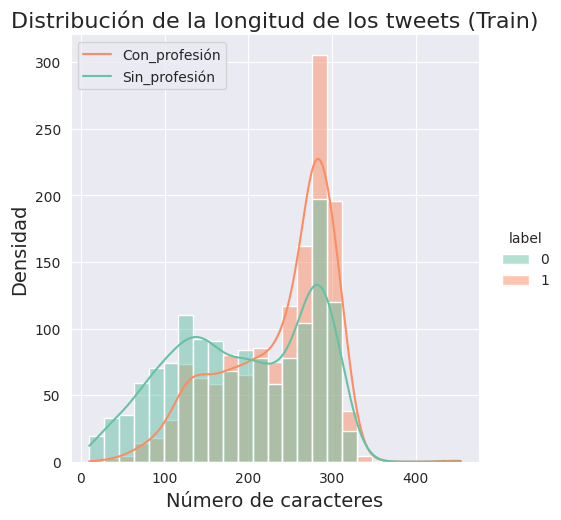

<Figure size 1400x600 with 0 Axes>

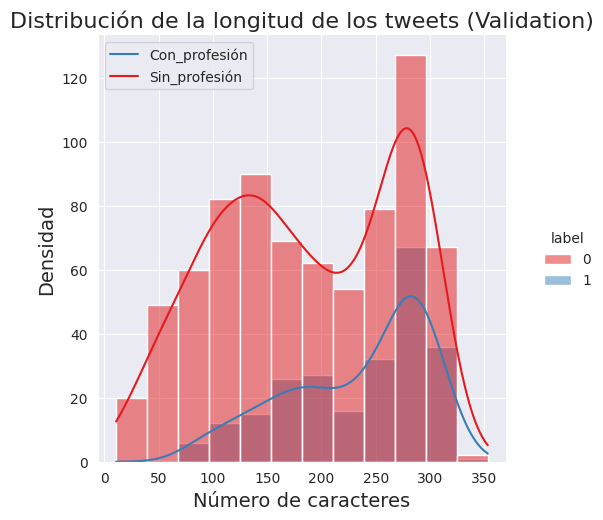

In [12]:
dataset_train_df['char_len'] = dataset_train_df['text'].apply(lambda x: len(x))
dataset_val_df['char_len'] = dataset_val_df['text'].apply(lambda x: len(x))

sns.set_style("darkgrid")

# Train
plt.figure(figsize=(14, 6))
sns.displot(data=dataset_train_df, x="char_len", hue="label", kde=True, palette="Set2")
plt.title("Distribución de la longitud de los tweets (Train)", fontsize=16)
plt.xlabel("Número de caracteres", fontsize=14)
plt.ylabel("Densidad", fontsize=14)
plt.legend(["Con_profesión", "Sin_profesión"])
plt.show()

# Validation
plt.figure(figsize=(14, 6))
sns.displot(data=dataset_val_df, x="char_len", hue="label", kde=True, palette="Set1")
plt.title("Distribución de la longitud de los tweets (Validation)", fontsize=16)
plt.xlabel("Número de caracteres", fontsize=14)
plt.ylabel("Densidad", fontsize=14)
plt.legend(["Con_profesión", "Sin_profesión"])
plt.show()



**Análisis de contenido de los tweets**

Para ello utiliza wordclouds

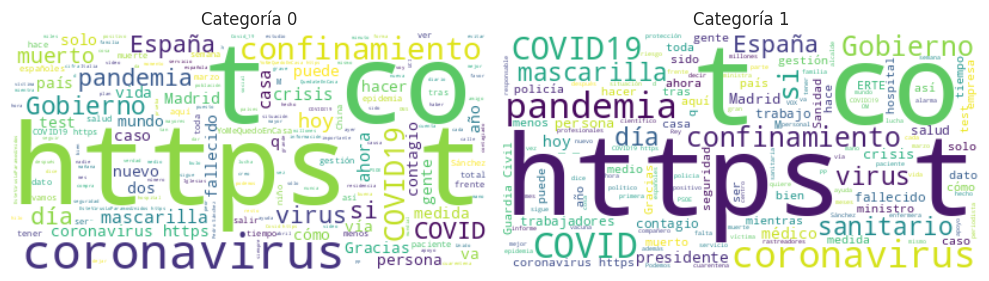

In [17]:

txt_cat0 = ",".join(dataset_train_df[dataset_train_df.label==0].text.to_list())
txt_cat1 = ",".join(dataset_train_df[dataset_train_df.label==1].text.to_list())


#Se usa WordCloud con stopwords y normalización de plurales para una mejor limpieza textual
en_stopwords = stopwords.words('spanish')

wordcloud_0 = WordCloud(background_color='white',max_words=5000, contour_width=0,
                      contour_color='steelblue', stopwords=en_stopwords,
                      normalize_plurals = True).generate(txt_cat0)

wordcloud_1 = WordCloud(background_color='white',max_words=5000, contour_width=0,
                      contour_color='steelblue', stopwords=en_stopwords,
                      normalize_plurals = True).generate(txt_cat1)


# Crear una figura con 2 subplots
plt.figure(figsize=(10, 6))

# Subplot 1 - Categoría 0
plt.subplot(1, 2, 1)
plt.imshow(wordcloud_0, interpolation='bilinear')
plt.axis('off')
plt.title("Categoría 0")

# Subplot 2 - Categoría 1
plt.subplot(1, 2, 2)
plt.imshow(wordcloud_1, interpolation='bilinear')
plt.axis('off')
plt.title("Categoría 1")

plt.tight_layout()
plt.show()

In [15]:
import re
def limpiar_texto(texto):
    texto = re.sub(r"http\S+", "", texto)  # eliminar URLs
    texto = re.sub(r"@\w+", "", texto)     # eliminar menciones
    texto = re.sub(r"#\w+", "", texto)     # eliminar hashtags
    return texto

# Aplicar limpieza al campo 'text' y guardar en una nueva columna 'text_clean'
dataset_train_df["text_clean"] = dataset_train_df["text"].apply(limpiar_texto)

# Unir todos los textos limpios
txt_cat0 = ",".join(dataset_train_df[dataset_train_df.label==0].text_clean.to_list())
txt_cat1 = ",".join(dataset_train_df[dataset_train_df.label==1].text_clean.to_list())


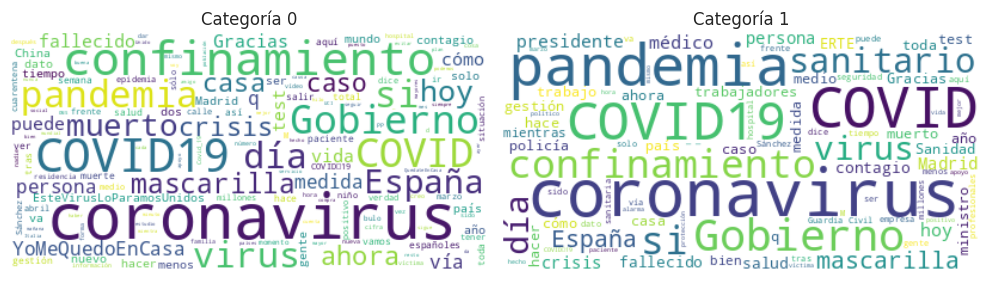

In [ ]:
wordcloud_0 = WordCloud(background_color='white',max_words=5000, contour_width=0,
                      contour_color='steelblue', stopwords=en_stopwords,
                      normalize_plurals = True).generate(txt_cat0)

wordcloud_1 = WordCloud(background_color='white',max_words=5000, contour_width=0,
                      contour_color='steelblue', stopwords=en_stopwords,
                      normalize_plurals = True).generate(txt_cat1)


# Crear una figura con 2 subplots
plt.figure(figsize=(10, 6))

# Subplot 1 - Categoría 0
plt.subplot(1, 2, 1)
plt.imshow(wordcloud_0, interpolation='bilinear')
plt.axis('off')
plt.title("Categoría 0")

# Subplot 2 - Categoría 1
plt.subplot(1, 2, 2)
plt.imshow(wordcloud_1, interpolation='bilinear')
plt.axis('off')
plt.title("Categoría 1")

plt.tight_layout()
plt.show()

**Conclusion:**
El análisis wordcloude sugiere que las diferencias léxicas entre las clases están alineadas con el objetivo del clasificador: los tweets con label = 1 contienen una carga semántica más centrada en el ámbito profesional o institucional, mientras que los de label = 0 tienen un enfoque más general.

Este análisis apoya la validez del etiquetado y ofrece una primera aproximación visual que justifica el desarrollo de un modelo de clasificación textual.


## Tokenización

El texto del dataset no está preparado para ser introducido en un modelo Transformers. Lleva a cabo el proceso de tokenización.

In [18]:
# IMPORTS
from transformers import AutoTokenizer


Antes de poder ajustar un modelo de lenguaje, necesitamos convertir nuestro texto en un formato que el modelo pueda entender. Esto se hace mediante el uso del tokenizador del modelo de lenguaje

Selecciona un modelo apropiado para la tarea:

> Recuerda que en la siguiente celda sólo debes asignar un valor a model_name. No añadas más información en la celda.

In [20]:
#NO-MODIFY: VARIABLE NAME
model_name = "PlanTL-GOB-ES/roberta-base-bne"

Puedes continuar con el proceso aquí:

In [21]:
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForMaskedLM

tokenizer = AutoTokenizer.from_pretrained(model_name)


tokenizer_config.json:   0%|          | 0.00/1.39k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/851k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/509k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.21M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/957 [00:00<?, ?B/s]

In [22]:
texto = "Durante la pandemia, los médicos y enfermeros trabajaron sin descanso."
texto_tokens = tokenizer.tokenize(texto)
print(texto_tokens)


['Durante', 'Ġla', 'Ġpand', 'emia', ',', 'Ġlos', 'ĠmÃ©dicos', 'Ġy', 'Ġenfermeros', 'Ġtrabajaron', 'Ġsin', 'Ġdescanso', '.']


In [23]:
def tokenize_function(example):
    return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )


In [24]:
tokenized_dataset = dataset.map(tokenize_function)


Map:   0%|          | 0/1001 [00:00<?, ? examples/s]

Map:   0%|          | 0/2786 [00:00<?, ? examples/s]

Map:   0%|          | 0/999 [00:00<?, ? examples/s]

In [25]:
tokenized_dataset['train'][0]

{'tweet_id': '1275401361073586177',
 'text': 'Las / os sanitarias / os no necesitan capas de superhéroes y superheroínas , necesitan fondos suficientes para los EPI que deben usar , para respiradores ... Exijámoslo 🧑 🏻\u200d ⚕ ️ 👩 🏻\u200d ⚕ ️ 👨 🏻\u200d ⚕ ️ # MFyC # COVID19 # DespuésDeAplaudir https://t.co/lizZEYp5Jj',
 'label': 1,
 'input_ids': [0,
  1014,
  2274,
  1649,
  17079,
  2274,
  1649,
  403,
  6877,
  16830,
  313,
  31889,
  342,
  1217,
  126,
  506,
  13611,
  275,
  66,
  6877,
  4494,
  9926,
  394,
  364,
  406,
  11845,
  341,
  3197,
  4239,
  275,
  66,
  394,
  15967,
  826,
  275,
  522,
  1879,
  3810,
  352,
  41959,
  8885,
  155,
  294,
  8885,
  292,
  174,
  38304,
  7473,
  303,
  298,
  275,
  14616,
  29421,
  157,
  8885,
  292,
  174,
  38304,
  7473,
  303,
  298,
  275,
  14616,
  29421,
  156,
  8885,
  292,
  174,
  38304,
  7473,
  303,
  298,
  275,
  14616,
  1121,
  404,
  92,
  143,
  89,
  1121,
  5138,
  20833,
  2428,
  1121,
  40154,
  110

## Fine-tuning

Carga el model para ser ajustado posteriormente:

In [28]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
import evaluate
import numpy as np


# Diccionarios para mapear las etiquetas numéricas a nombres (y viceversa)
id2label = {0: "SIN_PROFESION", 1: "CON_PROFESION"}
label2id = {"SIN_PROFESION": 0, "CON_PROFESION": 1}

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2, #clasificación binaria
    id2label=id2label,  #mapeo de índice a etiqueta
    label2id=label2id
)


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at PlanTL-GOB-ES/roberta-base-bne and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### Configuracion training_args

Configura los parámetros de entrenamiento del modelo.


>

> Recuerda que en la siguiente celda sólo debes asignar atributos a la variable training_args. No añadas  otras variables en la celda

In [29]:
#NO-MODIFY: VARIABLE NAME
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,  #Regularización para evitar overfitting (penaliza pesos grandes)
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True, #Cargar automáticamente el mejor modelo según la métrica evaluada
    logging_dir="./logs",
    logging_steps=50, #Frecuencia de logging (cada 50 pasos)
    push_to_hub=False,
    report_to="none",  #Desactivar logging a plataformas externas (WandB, TensorBoard, etc.)
    seed=42
)



### Métricas de evaluación

Define las métricas de evaluación

In [31]:

#Cargar las métricas desde la librería evaluate
accuracy = evaluate.load("accuracy")
f1_score = evaluate.load("f1")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred          # separar predicciones y etiquetas reales
    predictions = np.argmax(predictions, axis=1)          # convertir logits a etiquetas predichas
    accuracy_value = accuracy.compute(predictions=predictions, references=labels)["accuracy"]
    f1_score_value = f1_score.compute(predictions=predictions, references=labels)["f1"]

    return {
        "accuracy": accuracy_value,
        "f1_score": f1_score_value,
    }


### Ajuste del modelo

Lleva a cabo el ajuste del modelo:

In [32]:
train_dataset = tokenized_dataset['train']
val_dataset = tokenized_dataset['validation']
test_dataset = tokenized_dataset['test']

In [34]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)


/tmp/ipython-input-34-3012789700.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [35]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Score
1,0.242400,0.257129,0.932933,0.872865
2,0.105800,0.156680,0.959960,0.918367
3,0.031100,0.170635,0.958959,0.917505


TrainOutput(global_step=525, training_loss=0.17584187677928378, metrics={'train_runtime': 279.8225, 'train_samples_per_second': 29.869, 'train_steps_per_second': 1.876, 'total_flos': 549770550174720.0, 'train_loss': 0.17584187677928378, 'epoch': 3.0})

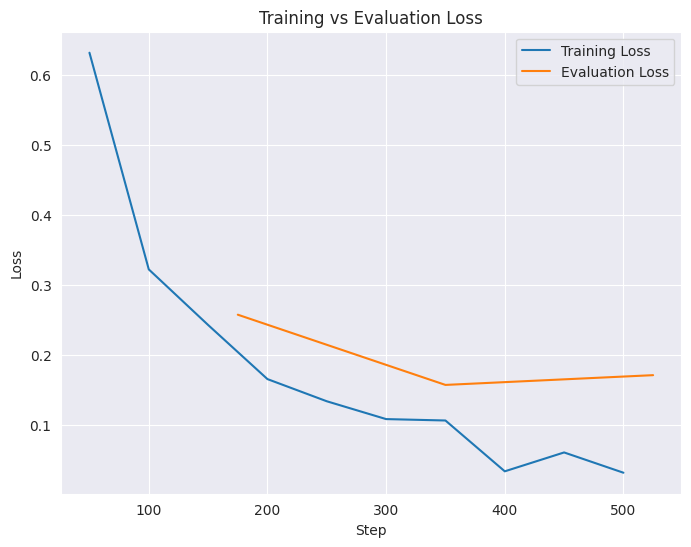

In [37]:
import pandas as pd

# Extraemos los logs de entrenamiento
history = pd.DataFrame(trainer.state.log_history)

# Filtramos filas con 'loss' y 'eval_loss'
train_loss = history[history['loss'].notna()][['step', 'loss']]
eval_loss = history[history['eval_loss'].notna()][['step', 'eval_loss']]

# Plot: curva de pérdida de entrenamiento vs validación
plt.figure(figsize=(8, 6))
plt.plot(train_loss['step'], train_loss['loss'], label='Training Loss')
plt.plot(eval_loss['step'], eval_loss['eval_loss'], label='Evaluation Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training vs Evaluation Loss')
plt.legend()
plt.grid(True)
plt.show()



Observation:

Pérdida de entrenamiento (blue): Disminuye constantemente, lo que indica que el modelo está aprendiendo bien.

Pérdida de evaluación (orange): Se estabiliza y es más alta, lo que es normal al trabajar con datos no vistos.

Posible sobreajuste: Al final, la pérdida de evaluación deja de bajar y podría estar subiendo, lo que sugiere que el modelo se está sobreajustando.

## Evaluacion

Una vez llevada a cabo el entrenamiento, realiza la evaluación del modelo.

In [38]:
val_dataset.to_pandas()["label"].value_counts()


,count
label,
0,761
1,238


In [39]:
results = trainer.evaluate()


In [40]:
print(results)


{'eval_loss': 0.1566799432039261, 'eval_accuracy': 0.95995995995996, 'eval_f1_score': 0.9183673469387755, 'eval_runtime': 6.7681, 'eval_samples_per_second': 147.604, 'eval_steps_per_second': 9.308, 'epoch': 3.0}


In [41]:
from sklearn.metrics import classification_report

# Hacer predicciones sobre el set de validación
val_preds_output = trainer.predict(val_dataset)
val_preds = val_preds_output.predictions.argmax(axis=1)
val_labels = val_preds_output.label_ids

# Mostrar clasificación detallada
print(classification_report(val_labels, val_preds))


              precision    recall  f1-score   support

           0       0.98      0.96      0.97       761
           1       0.89      0.95      0.92       238

    accuracy                           0.96       999
   macro avg       0.94      0.95      0.95       999
weighted avg       0.96      0.96      0.96       999



A partir de los resultados obtenidos sobre el conjunto de validación, se observa que el modelo presenta un excelente rendimiento general, con una **accuracy del 96%** y un **F1-score macro de 0.95**. La clase mayoritaria (tweets sin mención de profesión) presenta una precisión y recall muy altos, mientras que la clase minoritaria (tweets con profesión) también obtiene un desempeño notable, especialmente en términos de recall (0.95), lo que indica una **gran capacidad del modelo para identificar correctamente menciones profesionales**.

Aunque la precisión para la clase 1 es ligeramente más baja (0.89), el alto recall compensa esta diferencia y resulta adecuado para un problema donde es importante **minimizar los falsos negativos** (es decir, no pasar por alto profesiones mencionadas en los tweets).


## Genera predicciones

[link text](https://)Genera predicciones sobre el test set. Recuerda que el archivo que generes y adjuntes al ejercicio debe tener dos columnas:


| id         | label |
|------------|-------|
| 1234567890 | 1     |
| 1234567891 | 0     |
| 1234567892 | 0     |
| 1234567893 | 1     |

- El archivo debe estar en formato **TSV** (separado por tabuladores).
- Debe contener exactamente **dos columnas**: `id` y `label`.
- Es obligatorio incluir la **cabecera**.


In [42]:
test_dataset[0]

{'tweet_id': '1277969650051997701',
 'text': 'Esto es vergonzoso : una limpiadora de un hospital ha sido sancionada con 10 días sin sueldo por llamar la atención de altos cargos del centro que no usaban mascarillas . La limpiadora trabaja para la empresa Cecle , de Florentino Pérez . Piara de caciques . https://t.co/q50kHEMgZo',
 'label': -1,
 'input_ids': [0,
  2708,
  347,
  35751,
  275,
  80,
  405,
  4354,
  1678,
  313,
  355,
  4509,
  380,
  973,
  1533,
  7225,
  350,
  1472,
  1243,
  580,
  10156,
  383,
  7137,
  332,
  2649,
  313,
  7700,
  6272,
  369,
  1614,
  341,
  403,
  43048,
  29526,
  2436,
  275,
  68,
  859,
  4354,
  1678,
  6140,
  394,
  332,
  1303,
  379,
  390,
  371,
  275,
  66,
  313,
  23708,
  4157,
  275,
  68,
  6412,
  571,
  313,
  40336,
  2323,
  275,
  68,
  4217,
  1419,
  138,
  68,
  468,
  69,
  135,
  3260,
  129,
  94,
  3239,
  125,
  32326,
  2,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,


In [43]:
test_dataset = test_dataset.remove_columns("label")


In [44]:
predictions = trainer.predict(test_dataset)

In [45]:
predictions[0]

array([[-2.5182939,  2.737602 ],
       [ 2.5049694, -2.677778 ],
       [ 2.527523 , -2.714315 ],
       ...,
       [ 2.300654 , -2.5012767],
       [ 2.5062406, -2.74352  ],
       [ 2.416514 , -2.5295448]], dtype=float32)

In [46]:
# Extraemos los logits generados por el modelo (puntuaciones por clase antes de aplicar softmax)
logits = predictions.predictions

# Convertimos los logits en etiquetas predichas: seleccionamos la clase con mayor puntuación
y_pred  = logits.argmax(axis=1)


In [47]:
tweet_id = test_dataset["tweet_id"]

In [48]:
df = pd.DataFrame({"id": tweet_id, "label": y_pred})
df.to_csv("text_mining.tsv", sep="\t", index=False)


**Conclusion**

Se han probado tres modelos preentrenados en español con el objetivo de clasificar menciones a profesiones en tweets:

- `dccuchile/bert-base-spanish-wwm-cased`
- `bertin-project/bertin-roberta-base-spanish`
- `PlanTL-GOB-ES/roberta-base-bne`

Los resultados muestran que el modelo `PlanTL-GOB-ES/roberta-base-bne` ofrece el mejor rendimiento general, alcanzando un F1 Score de **0.9139** y una Accuracy de **0.9579** en training set. Esto sugiere que su preentrenamiento con textos oficiales y de alta calidad le proporciona una mejor capacidad de generalización incluso en el contexto de lenguaje informal como los tweets.

Por tanto, este modelo fue seleccionado para generar las predicciones finales sobre el conjunto de test.


Aunque se trata de tweets, la tarea consiste en identificar profesiones, no en comprender jerga o emociones.
El enfoque de la tarea está en detectar si se menciona una profesión, no en inferir emociones, intenciones ni interpretar abreviaciones o lenguaje coloquial.

El corpus de entrenamiento de PlanTL-GOB-ES contiene una gran cantidad de términos relacionados con el sector público y las profesiones, por lo que el modelo es más sensible al reconocimiento de sustantivos como “médico”, “enfermero” o “policía”.

En cambio, aunque bertin-project está adaptado al lenguaje informal, su cobertura sobre términos relacionados con profesiones podría no ser tan precisa como la de PlanTL-GOB-ES.


***El modelo PlanTL-GOB-ES/roberta-base-bne ha demostrado el mejor rendimiento debido a su arquitectura basada en RoBERTa y su preentrenamiento con textos formales y públicos en español que incluyen gran variedad de menciones a profesiones, lo cual resulta especialmente adecuado para la tarea de clasificación planteada.***